First 5 rows of the dataset:
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  

Dataset shape (rows, columns): (1000, 8)

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
D

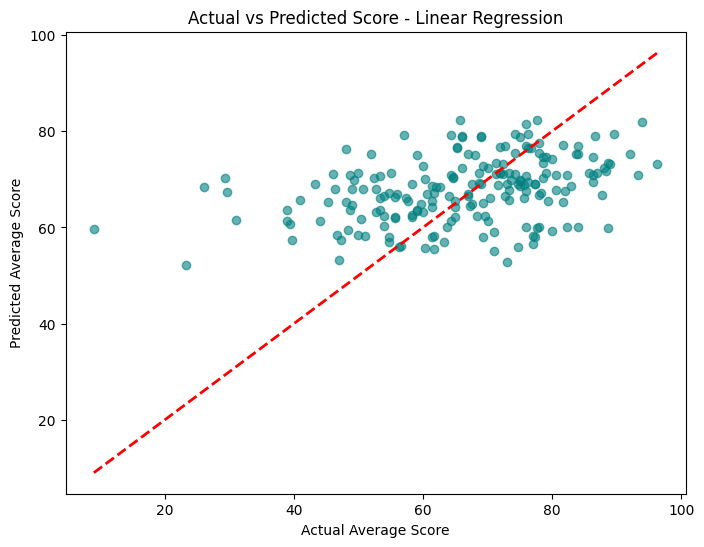

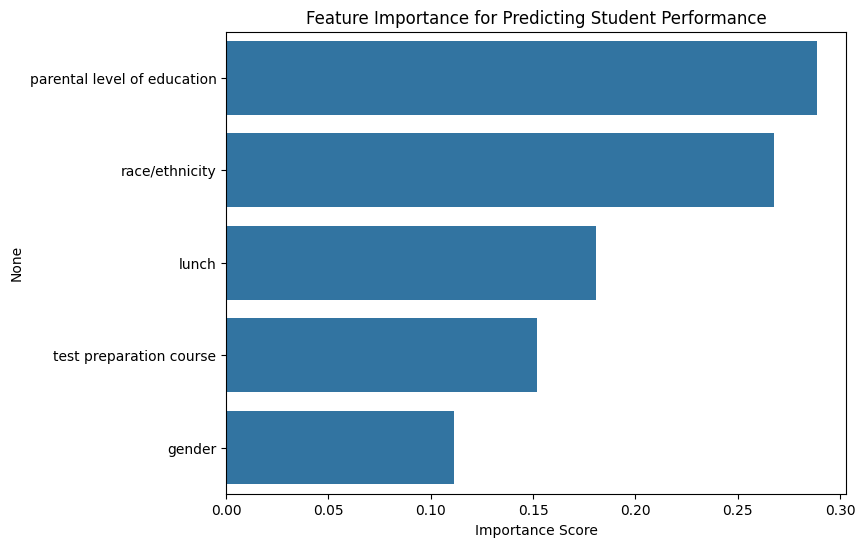


===== Summary =====
Best Model: Linear Regression
R2 Score: 0.126
(R2 Score closer to 1 means the model predicts better)


In [8]:
# =========================================================
# TASK 2: Student Performance Prediction
# =========================================================
# This script does the following step by step:
# 1. Load the data
# 2. Understand and clean the data (preprocessing)
# 3. Train regression models (to predict final average score)
# 4. Evaluate the models and visualize the results
# =========================================================

# ---- Step 1: Import required libraries ----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---- Step 2: Load the dataset ----
# NOTE: The dataset file must be uploaded to Colab first
# Kaggle dataset file is usually named 'StudentsPerformance.csv'
# If your file has a different name, update it below
df = pd.read_csv('/StudentsPerformance.csv')

print("First 5 rows of the dataset:")
print(df.head())

print("\nDataset shape (rows, columns):", df.shape)

print("\nColumn info:")
print(df.info())

print("\nChecking for missing values:")
print(df.isnull().sum())

# ---- Step 3: This dataset usually has three scores ----
# math score, reading score, writing score
# We create a new "average_score" column, which we will treat as our target
print("\nColumn names:")
print(df.columns.tolist())

# Column names may vary slightly by dataset version (spaces/underscores)
# Here we assume columns are named: 'math score', 'reading score', 'writing score'
df['average_score'] = (df['math score'] + df['reading score'] + df['writing score']) / 3

print("\nFirst 5 rows after adding 'average_score' column:")
print(df.head())

# ---- Step 4: Encode categorical columns ----
# Models only understand numbers, so text columns (gender, race,
# parental education, etc.) need to be converted into numbers
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(f"\nCategorical columns: {categorical_cols}")

le = LabelEncoder()
df_encoded = df.copy()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# ---- Step 5: Separate Features (X) and Target (y) ----
# We drop math/reading/writing score and use the remaining features
# to predict average_score (to avoid data leakage)
X = df_encoded.drop(['math score', 'reading score', 'writing score', 'average_score'], axis=1)
y = df_encoded['average_score']

print(f"\nFeatures used: {X.columns.tolist()}")

# ---- Step 6: Train/Test split ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining data: {X_train.shape[0]} rows")
print(f"Testing data: {X_test.shape[0]} rows")

# ---- Step 7: Feature Scaling (for Linear Regression) ----
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---- Step 8: Train and compare multiple regression models ----
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

results = {}

for name, model in models.items():
    if name == "Linear Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results[name] = {"MAE": mae, "RMSE": rmse, "R2 Score": r2}

    print(f"\n===== {name} =====")
    print(f"MAE (Mean Absolute Error): {mae:.3f}")
    print(f"RMSE (Root Mean Squared Error): {rmse:.3f}")
    print(f"R2 Score (closer to 1 = better fit): {r2:.3f}")

# ---- Step 9: Compare all model results in a table ----
results_df = pd.DataFrame(results).T
print("\n===== Comparison of All Models =====")
print(results_df)

# ---- Step 10: Identify the best model (based on R2 Score) ----
best_model_name = results_df['R2 Score'].idxmax()
print(f"\nBest model (based on R2 Score): {best_model_name}")

best_model = models[best_model_name]
if best_model_name == "Linear Regression":
    y_pred_best = best_model.predict(X_test_scaled)
else:
    y_pred_best = best_model.predict(X_test)

# ---- Step 11: Plot Actual vs Predicted scores ----
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.6, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Average Score')
plt.ylabel('Predicted Average Score')
plt.title(f'Actual vs Predicted Score - {best_model_name}')
plt.show()

# ---- Step 12: Feature Importance (using Random Forest) ----
rf_model = models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance for Predicting Student Performance")
plt.xlabel("Importance Score")
plt.show()

print("\n===== Summary =====")
print(f"Best Model: {best_model_name}")
print(f"R2 Score: {results[best_model_name]['R2 Score']:.3f}")
print("(R2 Score closer to 1 means the model predicts better)")
